# Imports

In [1]:
from torch_geometric.nn import HGTConv, Linear
from torch_geometric.loader import HGTLoader
from torch_geometric.data import HeteroData
import torch.nn.functional as F
# import pickle5 as pickle
import pickle
import torch.nn as nn
import pandas as pd
from utils import *
import random
import torch
import copy

from tqdm import tqdm

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
node_type1 = 'drug'
node_type2 = 'disease'
rel = 'indication'

In [3]:
config = {
    "num_samples": 512,
    "batch_size": 164,
    "dropout": 0.5,
    "epochs": 300
}

# Load data

In [4]:
primekg_file = '../data/kg.csv'
df = pd.read_csv(primekg_file, sep =",")

/tmp/ipykernel_19366/259066371.py:2: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(primekg_file, sep =",")


### Get drugs and diseases which are used in indication relation.

In [5]:
drug_disease_pairs = df[df['relation']==rel]
drugs, diseases = [], []

for i, row in drug_disease_pairs.iterrows():
    if row['x_type'] == node_type1:
        drugs.append(row['x_index'])
    if row['x_type'] == node_type2:
        diseases.append(row['x_index'])
    
    if row['y_type'] == node_type1:
        drugs.append(row['y_index'])
    if row['y_type'] == node_type2:
        diseases.append(row['y_index'])
        
drugs, diseases = list(set(drugs)), list(set(diseases))

### Remove drug and disease nodes that do not contribute to at least one indication edge. 

In [6]:
to_remove = df[df['x_type']==node_type1]
to_remove = to_remove[~to_remove['x_index'].isin(drugs)]
df.drop(to_remove.index, inplace = True)

In [7]:
to_remove = df[df['y_type']==node_type1]
to_remove = to_remove[~to_remove['y_index'].isin(drugs)]
df.drop(to_remove.index, inplace = True)

In [8]:
to_remove = df[df['x_type']==node_type2]
to_remove = to_remove[~to_remove['x_index'].isin(diseases)]
df.drop(to_remove.index, inplace = True)

In [9]:
to_remove = df[df['y_type']==node_type2]
to_remove = to_remove[~to_remove['y_index'].isin(diseases)]
df.drop(to_remove.index, inplace = True)

### Make HeteroData object for the graph.

In [10]:
new_df = pd.DataFrame()
new_df[0] = df['x_type'] + '::' + df['x_index'].astype(str)
new_df[1] = df['relation']
new_df[2] = df['y_type'] + '::' +df['y_index'].astype(str)

In [11]:
df = new_df
df = df.drop_duplicates()
triplets = df.values.tolist()

In [12]:
entity_dictionary = {}
def insert_entry(entry, ent_type, dic):
    if ent_type not in dic:
        dic[ent_type] = {}
    ent_n_id = len(dic[ent_type])
    if entry not in dic[ent_type]:
         dic[ent_type][entry] = ent_n_id
    return dic

for triple in triplets:
    src = triple[0]
    split_src = src.split('::')
    src_type = split_src[0]
    dest = triple[2]
    split_dest = dest.split('::')
    dest_type = split_dest[0]
    insert_entry(src,src_type,entity_dictionary)
    insert_entry(dest,dest_type,entity_dictionary)

In [13]:
edge_dictionary={}
for triple in triplets:
    src = triple[0]
    split_src = src.split('::')
    src_type = split_src[0]
    dest = triple[2]
    split_dest = dest.split('::')
    dest_type = split_dest[0]
    
    src_int_id = entity_dictionary[src_type][src]
    dest_int_id = entity_dictionary[dest_type][dest]
    
    pair = (src_int_id,dest_int_id)
    etype = (src_type, triple[1],dest_type)
    if etype in edge_dictionary:
        edge_dictionary[etype] += [pair]
    else:
        edge_dictionary[etype] = [pair]

In [14]:
data = HeteroData()

for i, key in enumerate(entity_dictionary.keys()):
    if key != 'drug':
        data[key].x = (torch.ones((len(entity_dictionary[key]), 768)) * i)
    elif key == 'drug':
        data[key].x = (torch.rand((len(entity_dictionary[key]), 767)))
   
    data[key].id = torch.arange(len(entity_dictionary[key]))

for key in edge_dictionary:
    data[key].edge_index = torch.transpose(torch.IntTensor(edge_dictionary[key]), 0, 1).long().contiguous()

### Add initial embeddings.

In [15]:
embeddings = pd.read_pickle('../data/entities_embeddings.pkl')
smiles_embeddings = pd.read_pickle('../data/smiles_embeddings.pkl')

for i, row in smiles_embeddings.iterrows():
    if row['id'] in entity_dictionary['drug'].keys():
        drug_id = entity_dictionary['drug'][row['id']]
        data['drug'].x[drug_id] = torch.Tensor(row['embedding'])

for i, row in embeddings.iterrows():
    x_type = row['id'].split('::')[0]
    if x_type in data.node_types and row['id'] in entity_dictionary[x_type] and x_type != 'drug':
        id_ = entity_dictionary[x_type][row['id']]
        data[x_type].x[id_][:768] = torch.Tensor(row['embedding'])

### Load train and validation data of one fold.

In [16]:
file = open('../data/CV data/train1.pkl', 'rb')
train_data = pickle.load(file)

In [17]:
file = open('../data/CV data/val1.pkl', 'rb')
val_data = pickle.load(file)

### Creating mask.

In [18]:
drug_disease_num = train_data[(node_type1, rel, node_type2)]['edge_index'].shape[1]
mask = random.sample(range(drug_disease_num), int(drug_disease_num*0.8))
train_data[(node_type1, rel, node_type2)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type1, rel, node_type2)]['mask'][mask] = True

train_data[(node_type2, rel, node_type1)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type2, rel, node_type1)]['mask'][mask] = True

### Define model.

In [19]:
class HGT(nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads, num_layers, dropout):
        super().__init__()

        self.lin_dict = nn.ModuleDict()
        for node_type in train_data.node_types:
            self.lin_dict[node_type] = Linear(-1, hidden_channels[0])
            
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            conv = HGTConv(hidden_channels[i], hidden_channels[i+1], train_data.metadata(),
                           num_heads[i])
            self.convs.append(conv)
        
        self.lin = Linear(sum(hidden_channels[1:]), out_channels)
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            node_type: self.dropout(self.lin_dict[node_type](x).relu_())
            for node_type, x in x_dict.items()
        }
        out = {}
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)

            if out=={}:
                out = copy.copy(x_dict)
            else:
                out = {
                    node_type: torch.cat((out[node_type], x_dict[node_type]), dim=1)
                    for node_type, x in x_dict.items()
                }

        return F.relu(self.lin(out[node_type1])), F.relu(self.lin(out[node_type2]))

In [20]:
class MLPPredictor(nn.Module):
    def __init__(self, channel_num, dropout):
        super().__init__()
        self.L1 = nn.Linear(channel_num * 2, channel_num)
        self.L2 = nn.Linear(channel_num, 1)
        self.bn = nn.BatchNorm1d(num_features=channel_num)
        self.dropout = nn.Dropout(0.2)

    def forward(self, drug_embeddings, disease_embeddings):
        x = torch.cat((drug_embeddings, disease_embeddings), dim=1)
        x = F.relu(self.bn(self.L1(x)))
        x = self.dropout(x)
        x = self.L2(x)
        return x

In [21]:
def compute_loss(scores, labels):
    pos_weights = torch.clone(labels)
    pos_weights[pos_weights == 1] = ((labels==0).sum() / labels.shape[0])
    pos_weights[pos_weights == 0] = ((labels==1).sum() / labels.shape[0])
    
    return F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weights)
#     return F.binary_cross_entropy_with_logits(scores, labels)

In [22]:
def define_model(dropout):
    GNN = HGT(hidden_channels=[64, 64, 64, 64],
              out_channels=64,
              num_heads=[8, 8, 8],
              num_layers=3,
              dropout=dropout)

    pred = MLPPredictor(64, dropout)
    model = nn.Sequential(GNN, pred)
    model.to(device)
    
    return GNN, pred, model

In [23]:
def define_loaders(config):
    kwargs = {'batch_size': config['batch_size'], 'num_workers': 8, 'persistent_workers': True}
    
    train_loader = HGTLoader(train_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    val_loader = HGTLoader(val_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    return train_loader, val_loader

In [24]:
def edge_exists(edges, edge):
    edges = edges.to(device)
    edge = edge.to(device)
    return (edges == edge).all(dim=0).sum() > 0

### Make batches.

In [25]:
def make_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    mask = batch[(node_type1, rel, node_type2)]['mask']   
    
    batch_index = (edge_index[0] < batch_size)
    edge_index = edge_index[:, batch_index]
    mask = mask[batch_index]
    edge_label_index = edge_index[:, mask]
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source = random.randint(0, batch_size-1)
        dest = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source], [dest]])
        if edge_exists(edge_index, neg_edge):
            continue
        else:
            neg_edges_source.append(source)
            neg_edges_dest.append(dest)
    
    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)
    edge_index = edge_index[:, ~mask]

    batch[(node_type1, rel, node_type2)]['edge_index'] = edge_index
    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label
    
    batch[(node_type2, rel, node_type1)]['edge_index'] = edge_index
    temp = copy.copy(batch[(node_type2, rel, node_type1)]['edge_index'][0])
    batch[(node_type2, rel, node_type1)]['edge_index'][0] = batch[(node_type2, rel, node_type1)]['edge_index'][1]
    batch[(node_type2, rel, node_type1)]['edge_index'][1] = temp
    
    return batch

In [26]:
def make_test_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
    edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
    
    source = []
    dest = []
    labels = []
    for i in range(edge_label_index.shape[1]):
        if edge_label_index[0, i] in batch[node_type1]['id'] and edge_label_index[1, i] in batch[node_type2]['id'] \
        and ((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0]) < batch_size:
            if edge_label[i] == 1:
                source.append((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0])
                dest.append((batch[node_type2]['id'] == edge_label_index[1, i]).nonzero(as_tuple=True)[0])

    edge_label_index = torch.zeros(2, len(source)).long()
    edge_label_index[0] = torch.tensor(source)
    edge_label_index[1] = torch.tensor(dest)
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source_node = random.randint(0, batch_size-1)
        dest_node = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source_node], [dest_node]])
        neg_edge_in_orig_graph = torch.Tensor([[batch[node_type1]['id'][source_node]], [batch[node_type2]['id'][dest_node]]])
        if edge_exists(data[(node_type1, rel, node_type2)]['edge_index'], neg_edge_in_orig_graph):
            continue
        else:
            neg_edges_source.append(source_node)
            neg_edges_dest.append(dest_node)

    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)

    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label

    return batch

### Train

In [27]:
def train(GNN, pred, model, loader, optimizer):
    model.train()
    total_examples = total_loss = 0
    for i, batch in enumerate(iter(loader)):
        optimizer.zero_grad()
        batch = make_batch(batch)
        batch = batch.to(device)
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        if edge_label.shape[0] == 0:
            continue
        
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        out = pred(c, d)[:, 0]
        loss = compute_loss(out, edge_label)
        loss.backward()
        optimizer.step()

        total_examples += edge_label_index.shape[1]
        # total_loss += float(loss) * edge_label_index.shape[1]
        # 方案 B (更常用): 直接使用 .item()，它会自动 detach
        total_loss += loss.item() * edge_label_index.shape[1]

    return total_loss / total_examples

### Test

In [28]:
@torch.no_grad()
def test(GNN, pred, model, loader):
    model.eval()

    total_examples = total_correct = 0
    out, labels = torch.tensor([]).to(device), torch.tensor([]).to(device)
    source, dest = torch.tensor([]).to(device), torch.tensor([]).to(device)
    for batch in iter(loader):
        batch = make_test_batch(batch)
        batch = batch.to(device)
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        
        if edge_label.shape[0] == 0:
            continue
                
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        batch_out = pred(c, d)[:, 0]
        labels = torch.cat((labels, edge_label))
        out = torch.cat((out, batch_out))
        
        drugs = batch[node_type1]['id'][edge_label_index[0]]
        diseases = batch[node_type2]['id'][edge_label_index[1]]
        source = torch.cat((source, drugs))
        dest = torch.cat((dest, diseases))

    loss = compute_loss(out, labels)    
    return out, labels, source, dest, loss.cpu().numpy()

### Run

In [29]:
def run(config):
    losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    
    train_loader, val_loader = define_loaders(config)
    GNN, pred, model = define_model(config['dropout'])
    
    optimizer = torch.optim.AdamW(model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 
                                                           T_max=config['epochs'], 
                                                           eta_min=0, 
                                                           last_epoch=-1)
    for epoch in tqdm(range(config['epochs']), desc="Training Progress"):
    # for epoch in range(config['epochs']):
        loss = train(GNN, pred, model, train_loader, optimizer)
        out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
        write_to_out(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, ValLoss: {val_loss:.4f} \n')
        losses.append(loss)
        val_losses.append(val_loss)
        plot_losses(losses, val_losses)

        scheduler.step()
        # 手动打印当前学习率
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch}: Learning Rate = {current_lr}")
        
    torch.save(model.state_dict(), '../out/saved_model.h5')
    
    out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
    AUPR(out, labels)
    AUROC(out, labels)

Training Progress:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch: 00, Loss: 0.5181, ValLoss: 0.5125 



Training Progress:   0%|          | 1/300 [00:13<1:05:13, 13.09s/it]

Epoch 0: Learning Rate = 0.000999972584682756


Training Progress:   1%|          | 2/300 [00:23<57:05, 11.50s/it]  

...

Training Progress: 100%|█████████▉| 299/300 [51:22<00:10, 10.30s/it]

Epoch: 298, Loss: 0.1324, ValLoss: 0.2426 

Epoch 298: Learning Rate = 2.7415317243928465e-08


Training Progress: 100%|██████████| 300/300 [51:33<00:00, 10.31s/it]

Epoch: 299, Loss: 0.1365, ValLoss: 0.2334 

Epoch 299: Learning Rate = 0.0


AUPR: 0.937 



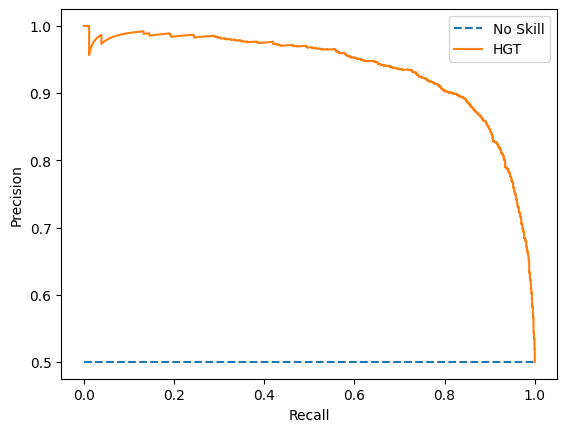

AUROC: 0.939 



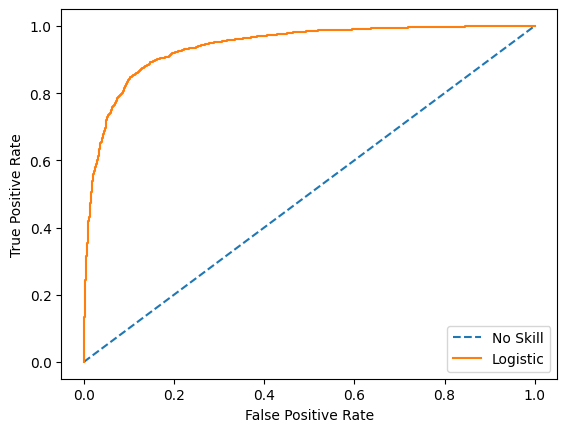

In [30]:
run(config)